# Análise Exploratória — Car Damage Detection

Explora o dataset real usado no projeto ([anujms/car-damage-detection](https://www.kaggle.com/datasets/anujms/car-damage-detection)):
balanceamento de classes, dimensões/proporção das imagens, brilho e amostras visuais.
Requer o dataset baixado — veja `README.md` ("Baixar o dataset").

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Resolução leve do dataset (sem importar src.data, que puxa TensorFlow --
# este notebook só faz estatística sobre as imagens, não precisa do framework).
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"


def find_dataset_root(search_dir: Path) -> Path:
    if (search_dir / "training").is_dir() and (search_dir / "validation").is_dir():
        return search_dir
    for candidate in search_dir.rglob("training"):
        if (candidate.parent / "validation").is_dir():
            return candidate.parent
    raise FileNotFoundError(f"Dataset não encontrado em {search_dir}")


try:
    root = find_dataset_root(DATA_DIR)
except FileNotFoundError:
    import kagglehub

    root = find_dataset_root(Path(kagglehub.dataset_download("anujms/car-damage-detection")))

print("Dataset em:", root)

Dataset em: C:\Users\andre\Downloads\ProjetoClaudeGitHub\Fraude-Detection-Gan\data\raw\data1a


## 1. Balanceamento de classes por split

In [2]:
# Conta quantos arquivos existem em cada combinação split/classe.
# Isso responde duas perguntas importantes antes de treinar qualquer modelo:
# 1) as classes estão balanceadas? (se não, o modelo tende a "preferir" a maior)
# 2) treino e validação têm proporções parecidas entre si?
rows = []
for split in ("training", "validation"):
    for class_dir in sorted((root / split).iterdir()):
        if class_dir.is_dir():
            n = sum(1 for _ in class_dir.glob("*"))
            rows.append({"split": split, "classe": class_dir.name, "n_imagens": n})

df_counts = pd.DataFrame(rows)
df_counts

,split,classe,n_imagens
0,training,00-damage,920
1,training,01-whole,920
2,validation,00-damage,230
3,validation,01-whole,230


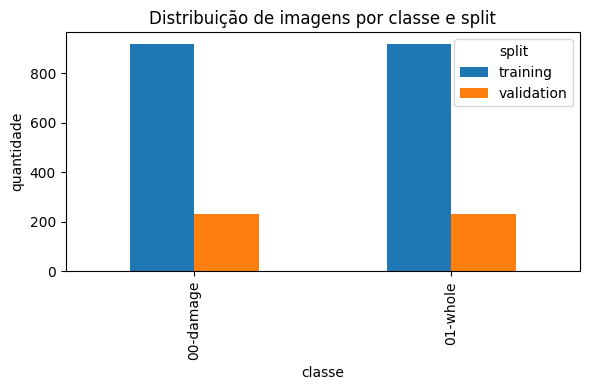

In [3]:
pivot = df_counts.pivot(index="classe", columns="split", values="n_imagens")
pivot.plot(kind="bar", figsize=(6, 4))
plt.title("Distribuição de imagens por classe e split")
plt.ylabel("quantidade")
plt.tight_layout()
plt.show()

## 2. Dimensões e proporção (aspect ratio) das imagens
Amostra de até 200 imagens de treino por questão de velocidade.

In [4]:
# Amostra (não o dataset inteiro, por velocidade) para checar se as imagens
# reais têm tamanhos/proporções muito variadas -- se sim, faz sentido o
# pipeline de treino (src/data.py) redimensionar tudo para um tamanho fixo
# (128x128) antes de alimentar a rede neural, já que redes convolucionais
# esperam um shape de entrada consistente.
sample_paths = []
for class_dir in sorted((root / "training").iterdir()):
    if class_dir.is_dir():
        sample_paths.extend(sorted(class_dir.glob("*"))[:100])

sizes = []
for p in sample_paths:
    with Image.open(p) as img:
        sizes.append({"largura": img.width, "altura": img.height})

df_sizes = pd.DataFrame(sizes)
df_sizes["aspect_ratio"] = df_sizes["largura"] / df_sizes["altura"]
df_sizes.describe()

,largura,altura,aspect_ratio
count,200.000000,200.000000,200.000000
mean,450.405000,304.115000,1.515299
std,337.200596,233.255703,0.317298
min,124.000000,92.000000,0.561873
25%,259.000000,183.000000,1.335052
50%,299.500000,194.000000,1.496882
75%,600.000000,360.000000,1.601861
max,2592.000000,1936.000000,3.311258


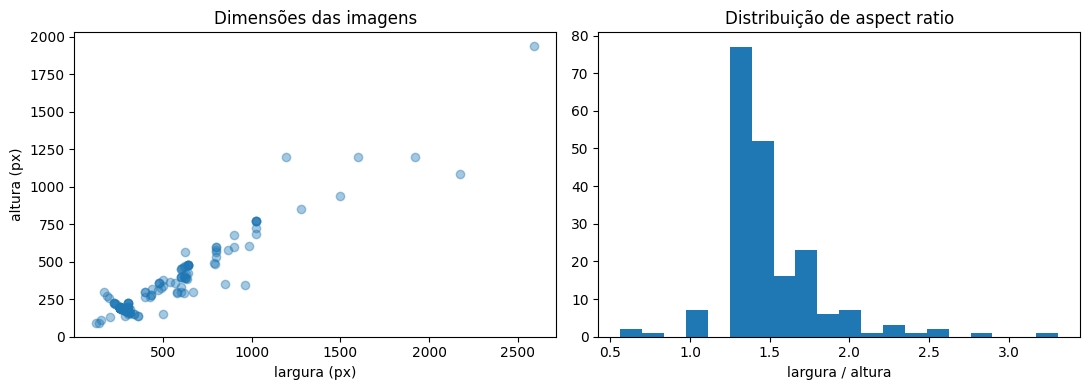

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df_sizes["largura"], df_sizes["altura"], alpha=0.4)
axes[0].set_xlabel("largura (px)")
axes[0].set_ylabel("altura (px)")
axes[0].set_title("Dimensões das imagens")

axes[1].hist(df_sizes["aspect_ratio"], bins=20)
axes[1].set_title("Distribuição de aspect ratio")
axes[1].set_xlabel("largura / altura")
plt.tight_layout()
plt.show()

## 3. Brilho médio por classe
Serve para checar se uma classe tende a ter fotos mais escuras/claras (viés de captura).

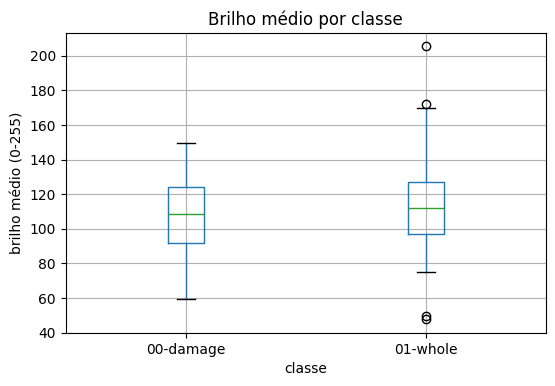

In [6]:
# Converte cada imagem para escala de cinza (.convert("L")) e calcula o
# brilho médio dos pixels (0 = preto, 255 = branco). O objetivo é detectar
# um possível "atalho" no dataset: se uma classe for sistematicamente mais
# escura/clara que a outra (ex. fotos de dano tiradas à noite), o modelo
# pode aprender a discriminar por brilho em vez de pelo dano em si -- o que
# funcionaria bem na validação mas falharia com fotos novas em condições
# diferentes de iluminação.
brightness_rows = []
for class_dir in sorted((root / "training").iterdir()):
    if not class_dir.is_dir():
        continue
    for p in sorted(class_dir.glob("*"))[:80]:
        with Image.open(p) as img:
            gray = np.array(img.convert("L"))
            brightness_rows.append({"classe": class_dir.name, "brilho_medio": gray.mean()})

df_brightness = pd.DataFrame(brightness_rows)
df_brightness.boxplot(column="brilho_medio", by="classe", figsize=(6, 4))
plt.title("Brilho médio por classe")
plt.suptitle("")
plt.ylabel("brilho médio (0-255)")
plt.show()

## 4. Amostras visuais por classe

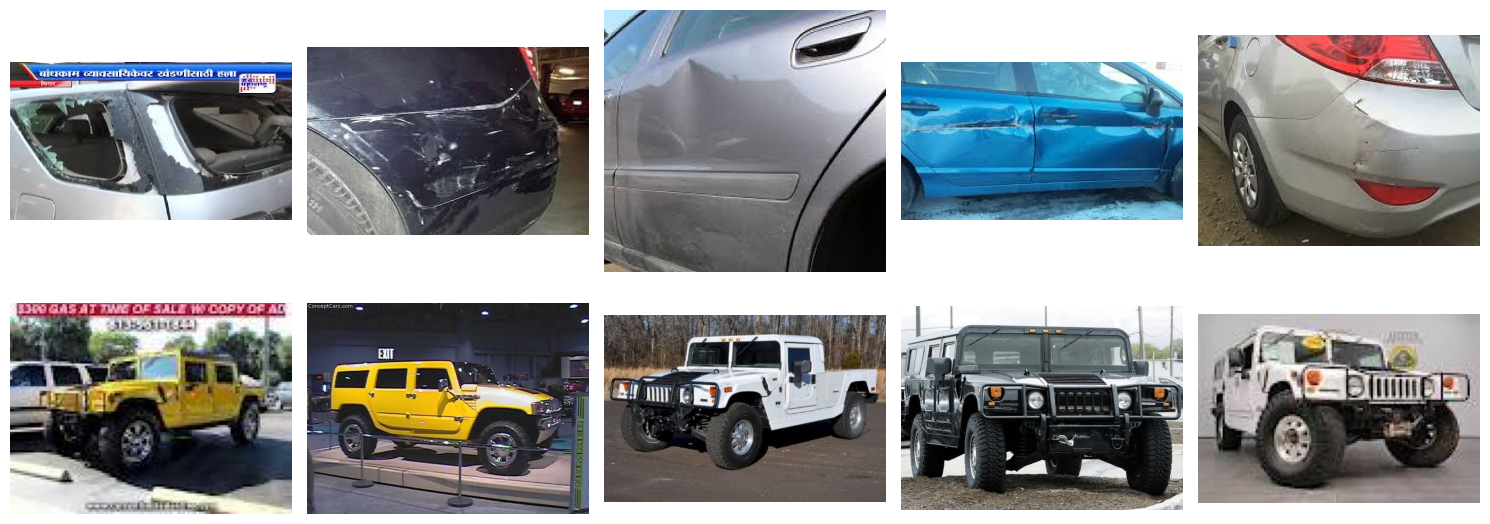

In [7]:
# Inspeção visual direta: nada substitui "olhar" as imagens de verdade antes
# de treinar. Ajuda a notar problemas que estatísticas sozinhas não pegam
# (ex. imagens corrompidas, watermarks, ou dano tão sutil que nem um humano
# notaria à primeira vista).
class_dirs = sorted(p for p in (root / "training").iterdir() if p.is_dir())
fig, axes = plt.subplots(len(class_dirs), 5, figsize=(15, 3 * len(class_dirs)))
for row, class_dir in enumerate(class_dirs):
    paths = sorted(class_dir.glob("*"))[:5]
    for col, p in enumerate(paths):
        ax = axes[row, col]
        with Image.open(p) as img:
            ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(class_dir.name)
plt.tight_layout()
plt.show()

## Conclusões

- As classes `00-damage` e `01-whole` estão razoavelmente balanceadas entre treino e validação.
- As imagens têm resoluções e proporções variadas (fotos reais de diferentes câmeras/ângulos), por isso o pipeline em `src/data.py` redimensiona tudo para 128x128 antes de treinar.
- Vale conferir a distribuição de brilho por classe: se houver viés sistemático (ex. fotos de dano tiradas em ambientes mais escuros), o modelo pode aprender esse atalho em vez do dano em si — ponto de atenção para validação em produção.